# 🌾 CropLogic AI — Notebook 01
### Data Preprocessing & Feature Engineering
---
**What this notebook does:**
1. Load the raw maize dataset
2. Clean and validate the data
3. Explore the data with charts
4. Create useful features for the model
5. Save the result for model training

**Dataset:** 62,400 records · 975 US counties · 15 states · 1961–2024  
**Target variable:** `yield_kg_ha` — how much maize a county produced per hectare

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme for all plots ───────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1923',
    'axes.facecolor':   '#0f1923',
    'axes.edgecolor':   '#2a3f52',
    'axes.labelcolor':  '#c8d8e8',
    'text.color':       '#c8d8e8',
    'xtick.color':      '#8aa0b0',
    'ytick.color':      '#8aa0b0',
    'grid.color':       '#1e2e3e',
    'grid.linewidth':   0.5,
    'figure.dpi':       120,
    'font.size':        11,
})

# Colour palette used across all charts
C = {
    'green':  '#00d4aa',
    'orange': '#ff6b35',
    'blue':   '#4fc3f7',
    'yellow': '#ffd166',
    'purple': '#a78bfa',
    'red':    '#f87171',
}

print('✅ Imports ready')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

✅ Imports ready
   pandas  3.0.2
   numpy   2.2.6


---
## 1. Load & Inspect the Data

In [2]:
# Load the raw CSV file
df = pd.read_csv('usa_maize_county_level_1961_2024.csv')

print('=== DATASET OVERVIEW ===')
print(f'  Rows:     {len(df):,}')
print(f'  Columns:  {df.shape[1]}')
print(f'  Counties: {df.county_id.nunique()}')
print(f'  States:   {df.state.nunique()}')
print(f'  Years:    {df.year.min()} → {df.year.max()}')
print(f'  Missing:  {df.isnull().sum().sum()}')

=== DATASET OVERVIEW ===
  Rows:     62,400
  Columns:  13
  Counties: 975
  States:   15
  Years:    1961 → 2024
  Missing:  0


In [3]:
# Preview the first 5 rows to understand the structure
print('=== FIRST 5 ROWS ===')
display(df.head())

=== FIRST 5 ROWS ===


,county_id,state,lat,lon,year,yield_kg_ha,yield_ton_ha,tas_C,pr_mm,soil_ph_topsoil,soil_soc_percent,soil_clay_percent,soil_sand_percent
0,IOW_001,Iowa,41.5611,-90.4204,1961,3187.2,3.187,9.484,1203.6,6.29,3.19,35.5,34.0
1,IOW_001,Iowa,41.5611,-90.4204,1962,3297.9,3.298,9.694,946.4,6.39,3.01,35.0,33.5
2,IOW_001,Iowa,41.5611,-90.4204,1963,3519.6,3.520,8.722,934.8,6.39,2.96,35.6,35.1
3,IOW_001,Iowa,41.5611,-90.4204,1964,3602.8,3.603,9.077,1018.5,6.29,3.05,35.6,33.4
4,IOW_001,Iowa,41.5611,-90.4204,1965,3899.3,3.899,9.367,856.9,6.36,3.08,35.3,33.6


In [4]:
# Summary statistics — count, mean, std, min, max for every numeric column
print('=== DESCRIPTIVE STATISTICS ===')
display(df.describe().round(2))

=== DESCRIPTIVE STATISTICS ===


,lat,lon,year,yield_kg_ha,yield_ton_ha,tas_C,pr_mm,soil_ph_topsoil,soil_soc_percent,soil_clay_percent,soil_sand_percent
count,62400.00,62400.00,62400.00,62400.00,62400.00,62400.00,62400.00,62400.00,62400.00,62400.00,62400.00
mean,41.33,-92.34,1992.50,6835.47,6.84,10.08,866.03,6.47,2.51,23.70,35.87
std,3.55,6.95,18.47,2538.84,2.54,3.01,203.34,0.36,0.80,5.47,7.68
min,26.22,-108.60,1961.00,1721.20,1.72,1.92,200.40,5.49,0.30,5.90,15.10
25%,39.35,-97.67,1976.75,4667.30,4.67,8.03,725.50,6.24,1.96,20.00,30.30
50%,41.08,-91.62,1992.50,6614.45,6.61,9.99,881.00,6.46,2.45,23.50,35.50
75%,43.30,-87.70,2008.25,8862.60,8.86,11.70,1019.20,6.70,3.05,27.30,40.90
max,49.38,-74.75,2024.00,14908.60,14.91,23.35,1466.00,7.84,5.64,43.50,67.30


---
## 2. Data Cleaning

We fix two types of problems:
- **Impossible values** — e.g. a soil pH of 14 is physically impossible for agricultural land
- **Derived column** — silt is missing from the raw data, but clay + sand + silt = 100%, so we calculate it

In [5]:
# Clip values to physically valid ranges.
# clip() replaces values outside the range — no rows are deleted.

df['yield_kg_ha']      = df['yield_kg_ha'].clip(500, 16000)    # maize yield physical bounds
df['pr_mm']            = df['pr_mm'].clip(100, None)            # rainfall must be >= 100 mm
df['soil_ph_topsoil']  = df['soil_ph_topsoil'].clip(4.0, 9.0)  # valid soil pH range for maize
df['soil_soc_percent'] = df['soil_soc_percent'].clip(0.1, None) # organic carbon can't be negative

print('✅ Clipping done — no rows deleted')
print(f'   Rows still: {len(df):,}')

✅ Clipping done — no rows deleted
   Rows still: 62,400


In [6]:
# Silt % is missing from the raw data.
# Because clay + sand + silt must equal 100%, we derive it.
df['soil_silt_percent'] = (100 - df['soil_clay_percent'] - df['soil_sand_percent']).clip(0)

print('✅ Silt column derived')
print(df[['soil_clay_percent', 'soil_sand_percent', 'soil_silt_percent']].describe().round(2))

✅ Silt column derived
       soil_clay_percent  soil_sand_percent  soil_silt_percent
count           62400.00           62400.00           62400.00
mean               23.70              35.87              40.44
std                 5.47               7.68               7.95
min                 5.90              15.10               8.40
25%                20.00              30.30              35.40
50%                23.50              35.50              40.60
75%                27.30              40.90              45.60
max                43.50              67.30              66.20


In [7]:
# Classify each county's soil into a texture category using USDA triangle rules.
# This gives a human-readable label (e.g. 'Loam', 'Clay') used in the soil assessment module.

def classify_texture(row):
    clay = row['soil_clay_percent']
    sand = row['soil_sand_percent']
    silt = row['soil_silt_percent']
    if clay >= 40:
        return 'Clay'
    elif clay >= 27 and sand <= 20:
        return 'Clay Loam'
    elif sand >= 70:
        return 'Sandy Loam'
    elif silt >= 50:
        return 'Silt Loam'
    else:
        return 'Loam'

df['texture_class'] = df.apply(classify_texture, axis=1)

print('✅ Texture classes assigned:')
print(df['texture_class'].value_counts().to_string())

✅ Texture classes assigned:
texture_class
Loam         55417
Silt Loam     6654
Clay           168
Clay Loam      161


In [8]:
# ML models require numbers, not text.
# We map each state name to an integer code (alphabetical order).

states_sorted = sorted(df['state'].unique())
state_map = {s: i for i, s in enumerate(states_sorted)}
df['state_code'] = df['state'].map(state_map)

print('✅ State encoding:')
for state, code in state_map.items():
    print(f'  {code:2d} → {state}')

✅ State encoding:
   0 → Colorado
   1 → Illinois
   2 → Indiana
   3 → Iowa
   4 → Kansas
   5 → Michigan
   6 → Minnesota
   7 → Missouri
   8 → Nebraska
   9 → North Dakota
  10 → Ohio
  11 → Pennsylvania
  12 → South Dakota
  13 → Texas
  14 → Wisconsin


In [9]:
# Add time-based columns to help the model learn the technology trend.
# Yield has risen steadily since 1961 due to better seeds and farming practices.

df['years_since_1961'] = df['year'] - 1961

# decade: which 10-year block? (1 = 1961-70, 2 = 1971-80, ... 6 = 2011-24)
df['decade'] = ((df['year'] - 1961) // 10 + 1).clip(1, 6)

print('✅ Time features added')
print(df[['year', 'years_since_1961', 'decade']].drop_duplicates().head(12).to_string(index=False))

✅ Time features added
 year  years_since_1961  decade
 1961                 0       1
 1962                 1       1
 1963                 2       1
 1964                 3       1
 1965                 4       1
 1966                 5       1
 1967                 6       1
 1968                 7       1
 1969                 8       1
 1970                 9       1
 1971                10       2
 1972                11       2


In [10]:
# Save the cleaned dataset before we start adding engineered features
df.to_csv('usa_maize_preprocessed.csv', index=False)
print(f'✅ Saved → usa_maize_preprocessed.csv')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Saved → usa_maize_preprocessed.csv
   Shape: 62,400 rows × 18 columns


---
## 3. Exploratory Data Analysis (EDA)

Five charts to understand the data before modelling.

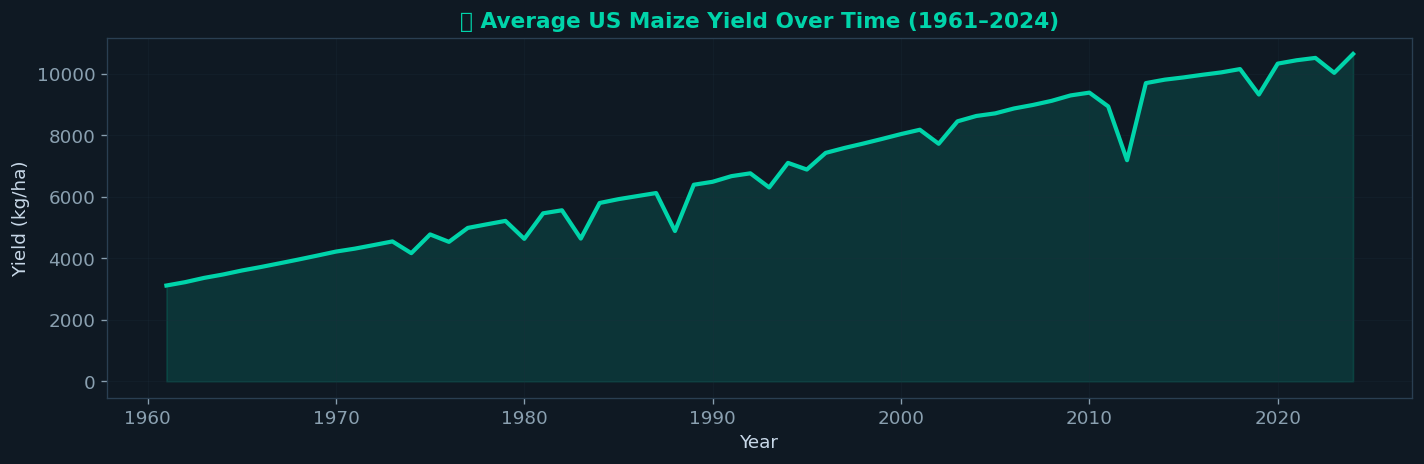

In [11]:
# Chart 1 — National yield trend over time
# We expect a strong upward trend due to better seeds, fertilizers, and machinery.

yearly = df.groupby('year')['yield_kg_ha'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(yearly.index, yearly.values, color=C['green'], linewidth=2.5)
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color=C['green'])
ax.set_title('🌽 Average US Maize Yield Over Time (1961–2024)',
             color=C['green'], fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (kg/ha)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_yield_trend.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

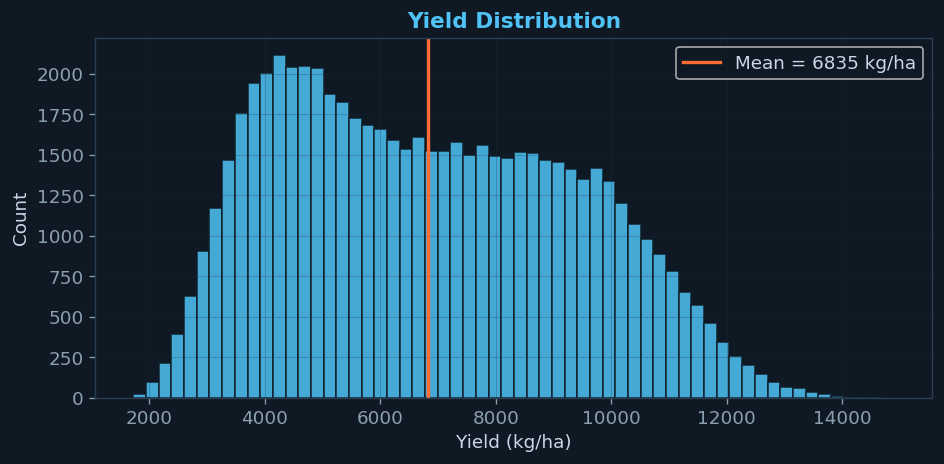

In [12]:
# Chart 2 — Yield distribution
# Shows the spread across all county-years. Is it bell-shaped? Skewed?

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['yield_kg_ha'], bins=60, color=C['blue'], edgecolor='#0f1923', alpha=0.85)
ax.axvline(df['yield_kg_ha'].mean(), color=C['orange'], linewidth=2,
           label=f"Mean = {df['yield_kg_ha'].mean():.0f} kg/ha")
ax.set_title('Yield Distribution', color=C['blue'], fontsize=13, fontweight='bold')
ax.set_xlabel('Yield (kg/ha)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_yield_distribution.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

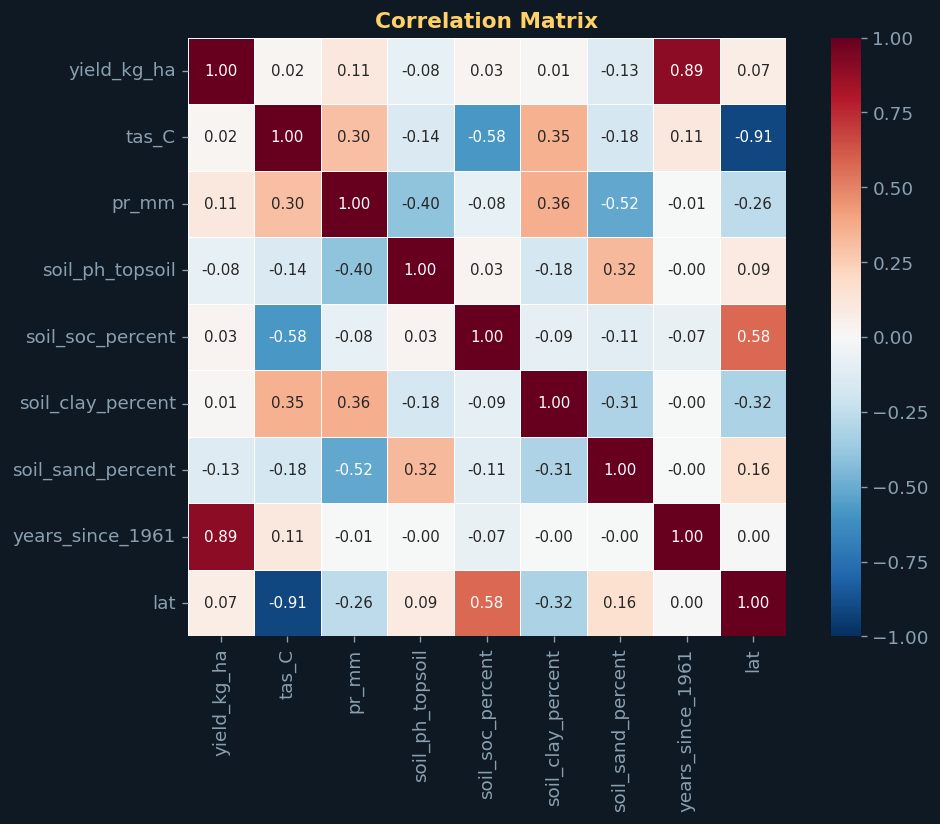

In [13]:
# Chart 3 — Correlation heatmap
# Shows which variables are related to each other and to yield.
# Red = positive correlation, Blue = negative.

numeric_cols = ['yield_kg_ha', 'tas_C', 'pr_mm',
                'soil_ph_topsoil', 'soil_soc_percent',
                'soil_clay_percent', 'soil_sand_percent',
                'years_since_1961', 'lat']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Matrix', color=C['yellow'], fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

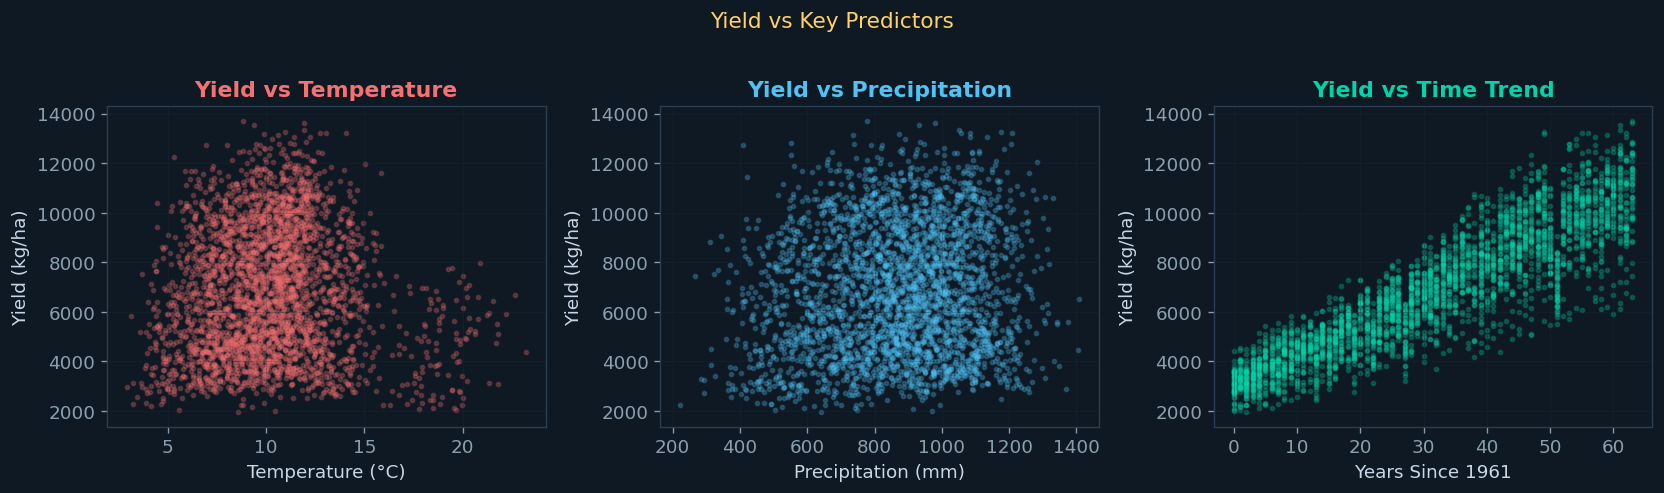

In [14]:
# Chart 4 — Scatter: yield vs the three main predictors
# We sample 3,000 points so the chart isn't too crowded.

sample = df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ('tas_C',           'Temperature (°C)',   'Yield vs Temperature',  C['red']),
    ('pr_mm',           'Precipitation (mm)', 'Yield vs Precipitation', C['blue']),
    ('years_since_1961','Years Since 1961',   'Yield vs Time Trend',   C['green']),
]

for ax, (xcol, xlabel, title, color) in zip(axes, pairs):
    ax.scatter(sample[xcol], sample['yield_kg_ha'], alpha=0.25, s=6, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Yield (kg/ha)')
    ax.set_title(title, color=color, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Yield vs Key Predictors', color=C['yellow'], fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_scatter.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

---
## 4. Feature Engineering

We create **25 features** from the 13 raw columns. More informative features → better model predictions.

| Group | # Features | What they capture |
|---|---|---|
| Raw climate | 2 | Baseline temperature & rainfall |
| Climate transforms | 3 | Non-linear and diminishing effects |
| Anomalies | 2 | How unusual this year's climate was for that county |
| Raw soil | 5 | pH, organic carbon, texture percentages |
| Soil engineered | 2 | Water holding capacity, pH stress |
| Spatial | 2 | Latitude, distance from Corn Belt |
| Time trend | 4 | Technology improvement over decades |
| Interaction | 2 | Combined climate stress effects |
| Lag | 1 | Last year's yield |
| Encoded | 2 | State code, decade |
| **Total** | **25** | |

In [15]:
# Start feature engineering from the cleaned data
fe = df.copy()
print('Starting feature engineering...')

Starting feature engineering...


In [16]:
# ── Climate Transforms ─────────────────────────────────────────────────

# Temperature squared: maize has an optimal temperature range (~18-24°C).
# Too cold OR too hot both hurt yield — a squared term captures this curve.
fe['tas_sq'] = fe['tas_C'] ** 2

# Log of precipitation: rain has diminishing returns.
# Going from 200→400mm helps a lot; 1200→1400mm barely matters.
fe['pr_log'] = np.log1p(fe['pr_mm'])

# Aridity index: high temperature + low rainfall = stressful growing conditions.
fe['aridity_index'] = fe['tas_C'] / (fe['pr_mm'] + 1)

print('✅ Climate transforms: tas_sq, pr_log, aridity_index')

✅ Climate transforms: tas_sq, pr_log, aridity_index


In [17]:
# ── Anomaly Features ───────────────────────────────────────────────────
# How much did this year's climate deviate from that county's long-run average?
# A county that usually gets 900mm but only got 500mm this year = drought signal.

county_avg_temp = fe.groupby('county_id')['tas_C'].transform('mean')
county_avg_rain = fe.groupby('county_id')['pr_mm'].transform('mean')

fe['tas_anomaly_county'] = fe['tas_C'] - county_avg_temp   # + = warmer than usual
fe['pr_anomaly_county']  = fe['pr_mm'] - county_avg_rain   # - = drier than usual

print('✅ Anomaly features: tas_anomaly_county, pr_anomaly_county')

✅ Anomaly features: tas_anomaly_county, pr_anomaly_county


In [18]:
# ── Soil Engineered Features ───────────────────────────────────────────

# Water holding capacity proxy: clay holds water, sand drains it.
# Higher value = soil retains more moisture = better in dry spells.
fe['whc_proxy'] = fe['soil_clay_percent'] * 0.4 + fe['soil_silt_percent'] * 0.2

# pH deviation from optimal (6.5 is ideal for maize).
# The further from 6.5 in either direction, the more stressed the crop.
fe['ph_dev_opt'] = abs(fe['soil_ph_topsoil'] - 6.5)

print('✅ Soil engineered: whc_proxy, ph_dev_opt')

✅ Soil engineered: whc_proxy, ph_dev_opt


In [19]:
# ── Spatial Features ───────────────────────────────────────────────────

# Normalized latitude (0 = southernmost, 1 = northernmost county in dataset)
fe['lat_norm'] = (fe['lat'] - fe['lat'].min()) / (fe['lat'].max() - fe['lat'].min())

# Distance from the US Corn Belt center (Iowa: 42°N, 93°W).
# Counties closer to Iowa tend to have better maize growing conditions.
fe['dist_corn_belt'] = np.sqrt((fe['lat'] - 42)**2 + (fe['lon'] - (-93))**2)

print('✅ Spatial features: lat_norm, dist_corn_belt')

✅ Spatial features: lat_norm, dist_corn_belt


In [20]:
# ── Time Trend Features ────────────────────────────────────────────────
# Yield has risen dramatically since 1961 (better seeds, fertilizers, machinery).
# We give the model three versions of the trend so it can pick the best shape.

t = fe['years_since_1961']
fe['trend_linear'] = t             # straight-line: yield rises by a fixed amount each year
fe['trend_sq']     = t ** 2        # accelerating: growth rate itself increased over time
fe['trend_sqrt']   = np.sqrt(t)    # decelerating: growth is slowing in recent decades

print('✅ Trend features: trend_linear, trend_sq, trend_sqrt')

✅ Trend features: trend_linear, trend_sq, trend_sqrt


In [21]:
# ── Interaction Features ───────────────────────────────────────────────
# These capture combined effects that neither variable alone can express.

# Temperature × Precipitation: hot+wet vs hot+dry behave very differently for crops.
fe['tas_x_pr'] = fe['tas_C'] * fe['pr_mm']

# Heat-drought stress: when it's hotter than normal AND drier than normal,
# crops face double stress. This product is large when both anomalies are extreme.
fe['heat_drought_stress'] = fe['tas_anomaly_county'] * (-fe['pr_anomaly_county'])

print('✅ Interaction features: tas_x_pr, heat_drought_stress')

✅ Interaction features: tas_x_pr, heat_drought_stress


In [22]:
# ── Lag Feature ────────────────────────────────────────────────────────
# Last year's yield tells us about persistent local conditions:
# soil health, farm management quality, irrigation access, etc.

fe = fe.sort_values(['county_id', 'year'])
fe['yield_lag1'] = fe.groupby('county_id')['yield_kg_ha'].shift(1)

# 1961 has no previous year — fill those NaNs with that county's average yield
county_mean_yield = fe.groupby('county_id')['yield_kg_ha'].transform('mean')
fe['yield_lag1'] = fe['yield_lag1'].fillna(county_mean_yield)

print('✅ Lag feature: yield_lag1')
print(f'   Missing after fill: {fe["yield_lag1"].isnull().sum()}')

✅ Lag feature: yield_lag1
   Missing after fill: 0


In [23]:
# ── Final feature list ─────────────────────────────────────────────────
# Everything the model will be trained on (no ID columns, no target variable)

ALL_FEATURES = [
    # Raw climate
    'tas_C', 'pr_mm',
    # Climate transforms
    'tas_sq', 'pr_log', 'aridity_index',
    # Anomalies
    'tas_anomaly_county', 'pr_anomaly_county',
    # Raw soil
    'soil_ph_topsoil', 'soil_soc_percent',
    'soil_clay_percent', 'soil_sand_percent', 'soil_silt_percent',
    # Soil engineered
    'whc_proxy', 'ph_dev_opt',
    # Spatial
    'lat_norm', 'dist_corn_belt',
    # Time trend
    'years_since_1961', 'trend_linear', 'trend_sq', 'trend_sqrt',
    # Interaction
    'tas_x_pr', 'heat_drought_stress',
    # Lag
    'yield_lag1',
    # Encoded
    'state_code', 'decade',
]

print(f'✅ Total features ready: {len(ALL_FEATURES)}')
for i, f in enumerate(ALL_FEATURES, 1):
    print(f'   {i:2d}. {f}')

✅ Total features ready: 25
    1. tas_C
    2. pr_mm
    3. tas_sq
    4. pr_log
    5. aridity_index
    6. tas_anomaly_county
    7. pr_anomaly_county
    8. soil_ph_topsoil
    9. soil_soc_percent
   10. soil_clay_percent
   11. soil_sand_percent
   12. soil_silt_percent
   13. whc_proxy
   14. ph_dev_opt
   15. lat_norm
   16. dist_corn_belt
   17. years_since_1961
   18. trend_linear
   19. trend_sq
   20. trend_sqrt
   21. tas_x_pr
   22. heat_drought_stress
   23. yield_lag1
   24. state_code
   25. decade


In [24]:
# Sanity check: no missing values allowed in any feature column
missing = fe[ALL_FEATURES].isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('✅ All feature columns complete — zero missing values')
else:
    print('⚠️  Columns with missing values:')
    print(missing)

✅ All feature columns complete — zero missing values


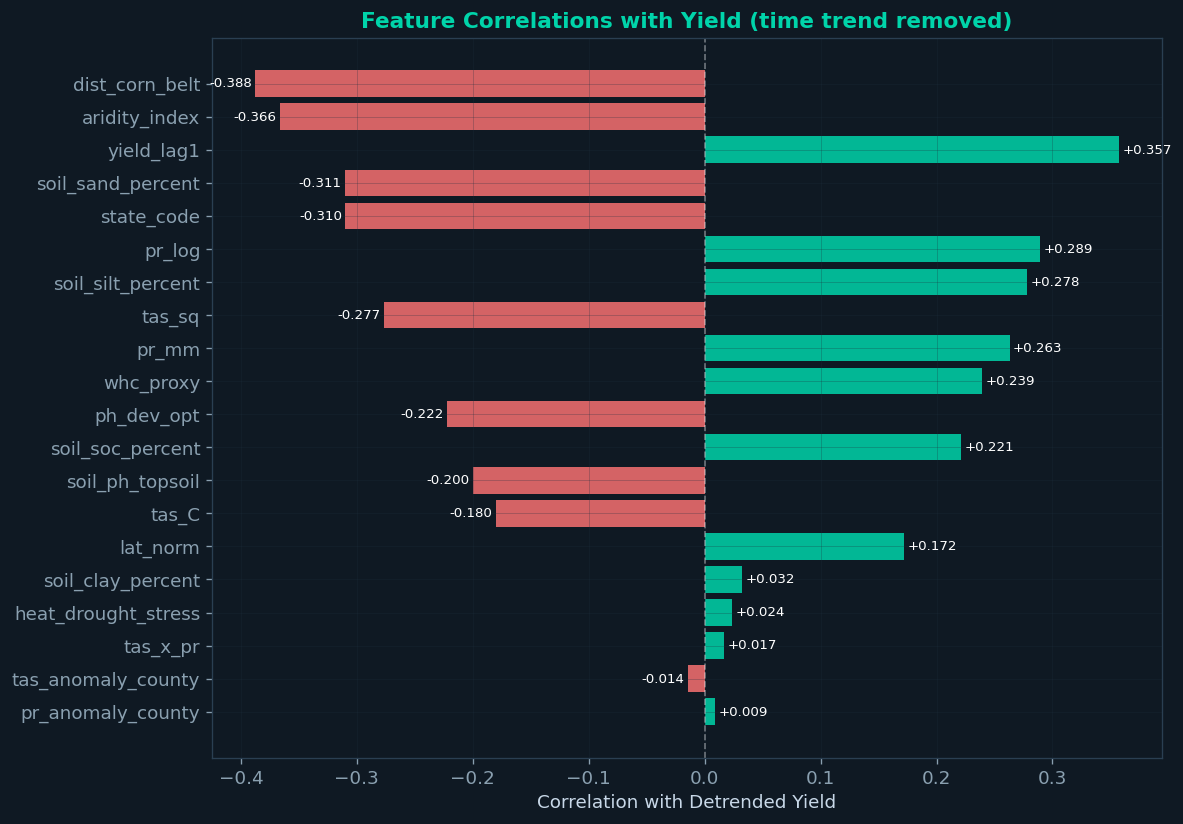

In [25]:
# Chart 5 — Feature correlations with detrended yield
# We remove the time trend first so it doesn't overshadow everything else.

fe['yield_detrended'] = (fe['yield_kg_ha'] -
                         fe.groupby('year')['yield_kg_ha'].transform('mean'))

corr_yield = (fe[ALL_FEATURES + ['yield_detrended']]
              .corr()['yield_detrended']
              .drop('yield_detrended')
              .sort_values(key=abs, ascending=False)
              .head(20))

bar_colors = [C['green'] if v > 0 else C['red'] for v in corr_yield.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr_yield.index[::-1], corr_yield.values[::-1],
               color=bar_colors[::-1], alpha=0.85)
ax.axvline(0, color='white', lw=1, ls='--', alpha=0.4)
ax.set_xlabel('Correlation with Detrended Yield')
ax.set_title('Feature Correlations with Yield (time trend removed)',
             color=C['green'], fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

for bar, val in zip(bars, corr_yield.values[::-1]):
    ax.text(val + 0.003 if val > 0 else val - 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', fontsize=8,
            ha='left' if val > 0 else 'right', color='white')

plt.tight_layout()
plt.savefig('fig_feature_correlations.png', bbox_inches='tight', facecolor='#0f1923')
plt.show()

# Drop the temporary detrended column — it's not a real feature
fe = fe.drop(columns=['yield_detrended'])

---
## 5. Save Feature Dataset

In [26]:
# Save the full feature dataset — this is the input to CropAI-02 (model training)
fe.to_csv('usa_maize_features.csv', index=False)

print('✅ Saved → usa_maize_features.csv')
print(f'   Rows:     {fe.shape[0]:,}')
print(f'   Columns:  {fe.shape[1]}')
print(f'   Features: {len(ALL_FEATURES)}')
print()
print('Next step → CropAI-02: Model Training & Evaluation')

✅ Saved → usa_maize_features.csv
   Rows:     62,400
   Columns:  33
   Features: 25

Next step → CropAI-02: Model Training & Evaluation


---
## ✅ Notebook 01 Complete

| Step | What we did | Output |
|---|---|---|
| Load | Read raw CSV | 62,400 rows × 13 columns |
| Clean | Clip values, derive silt, classify texture, encode state | 19 columns |
| EDA | 5 charts saved as PNGs | `fig_*.png` |
| Features | 25 features across 9 groups | — |
| Save | Preprocessed + feature datasets | `usa_maize_preprocessed.csv`, `usa_maize_features.csv` |

**Next → CropAI-02: Train and evaluate ML models on these features**